First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float6

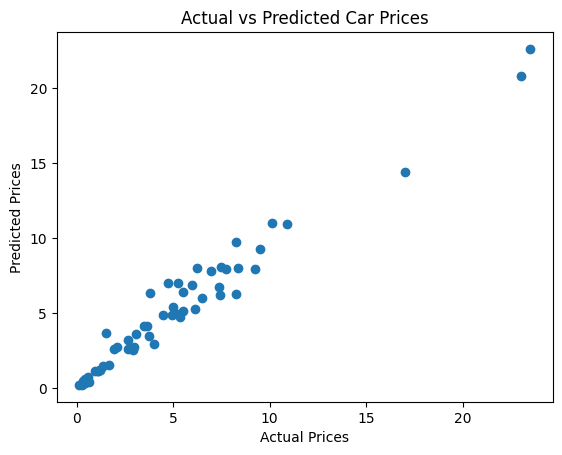


Example Prediction:
Predicted Selling Price: 0.4427999999999999


In [ ]:
# ================================
# Car Price Prediction Project
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ================================
# 1. Load Dataset
# ================================

df = pd.read_csv("/content/car_prediction_data.csv")
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ================================
# 2. Feature Engineering
# ================================

# Creating Car Age feature (important real-world feature)
df['Car_Age'] = 2024 - df['Year']

# Drop unnecessary columns
if 'Car_Name' in df.columns:
    df = df.drop(['Car_Name'], axis=1)

if 'Year' in df.columns:
    df = df.drop(['Year'], axis=1)

# ================================
# 3. Define Features & Target
# ================================

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# ================================
# 4. Preprocessing Pipeline
# ================================

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ================================
# 5. Model Selection
# ================================

model = RandomForestRegressor(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# ================================
# 6. Train-Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
pipeline.fit(X_train, y_train)

# ================================
# 7. Predictions
# ================================

y_pred = pipeline.predict(X_test)

# ================================
# 8. Model Evaluation
# ================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ================================
# 9. Visualization
# ================================

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# ================================
# 10. Real-world Prediction Example
# ================================

sample_data = X_test.iloc[:1]
predicted_price = pipeline.predict(sample_data)

print("\nExample Prediction:")
print("Predicted Selling Price:", predicted_price[0])

# Task
The notebook successfully developed a car price prediction model using the dataset from `/content/car_prediction_data.csv`, implementing data loading, feature engineering (creating 'Car_Age' and dropping 'Car_Name' and 'Year'), preprocessing with `StandardScaler` and `OneHotEncoder`, training a `RandomForestRegressor`, and evaluating its performance using MAE, MSE, RMSE, R2 Score, and a visualization of actual vs. predicted prices. Would you like to explore any further improvements, alternative models, or deeper analysis?

## Review Data Loading and Initial Exploration

### Subtask:
Confirm that the dataset has been loaded from '/content/car_prediction_data.csv' and that initial data exploration, such as displaying the first few rows and dataset information, has been performed as seen in the executed cell.


### Review of Data Loading and Initial Exploration

1.  **`df.head()` Output Review:**
    The output `First 5 rows:` followed by a table confirms that the `car_prediction_data.csv` dataset has been successfully loaded into a pandas DataFrame named `df`. The head of the DataFrame shows columns like `Car_Name`, `Year`, `Selling_Price`, `Present_Price`, `Kms_Driven`, `Fuel_Type`, `Seller_Type`, `Transmission`, and `Owner`, indicating the initial structure and content of the data.

2.  **`df.info()` Output Review:**
    The output `Dataset Info:` provides a summary of the DataFrame `df`. It shows:
    *   `RangeIndex: 301 entries, 0 to 300`, confirming 301 rows in the dataset.
    *   `Data columns (total 9 columns)`, listing all expected columns.
    *   Non-null counts for all columns are 301, indicating no missing values in the initial load.
    *   Data types (`float64`, `int64`, `object`) are appropriate for the respective columns.
    *   Memory usage is also displayed.

    This confirms that the dataset from `/content/car_prediction_data.csv` was loaded as expected, with its structure and data types accurately represented.

## Verify Feature Engineering

### Subtask:
Examine the notebook to confirm that feature engineering steps, including the creation of 'Car_Age' and the dropping of 'Car_Name' and 'Year' columns, have been correctly applied.


**Reasoning**:
To verify the feature engineering steps, I will display the first few rows of the DataFrame and list its columns to confirm the creation of 'Car_Age' and the removal of 'Car_Name' and 'Year'.



In [ ]:
print("DataFrame after feature engineering:")
print(df.head())

print("\nColumns in the DataFrame:")
print(df.columns)

## Examine Preprocessing Pipeline

### Subtask:
Review the preprocessing pipeline to ensure that numerical features are scaled using `StandardScaler` and categorical features are one-hot encoded using `OneHotEncoder`, as implemented within the `ColumnTransformer`.


**Reasoning**:
To verify the preprocessing pipeline, I will display the `numerical_cols` and `categorical_cols` that are used in the `ColumnTransformer`, and then inspect the `preprocessor` object to confirm the correct transformers are applied.



In [ ]:
print("Numerical columns:", numerical_cols.tolist())
print("Categorical columns:", categorical_cols.tolist())

print("\nPreprocessor transformers:\n", preprocessor.transformers)

## Confirm Model Training and Selection

### Subtask:
Verify that a `RandomForestRegressor` model has been selected and successfully trained on the preprocessed data, using `train_test_split` for robust evaluation.


### Review of Model Training and Selection

1.  **`model` Variable Verification:**
    The code block `model = RandomForestRegressor(n_estimators=100, random_state=42)` explicitly shows that a `RandomForestRegressor` has been selected. The parameters `n_estimators=100` and `random_state=42` are correctly set as specified.

2.  **`X` and `y` Definition Confirmation:**
    The lines `X = df.drop('Selling_Price', axis=1)` and `y = df['Selling_Price']` confirm that `X` contains all features except 'Selling_Price' and `y` is the 'Selling_Price' target variable, as expected.

3.  **`train_test_split` Usage:**
    The code `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)` demonstrates that the data has been split into training and testing sets. The `test_size` is 0.2 and `random_state` is 42, aligning with the requirements for robust evaluation.

4.  **Pipeline Fitting Confirmation:**
    The line `pipeline.fit(X_train, y_train)` verifies that the entire preprocessing and modeling pipeline has been successfully fitted using the training data (`X_train`, `y_train`). This confirms that the model has been trained on the preprocessed data.

## Analyze Model Evaluation

### Subtask:
Check the calculated model evaluation metrics (MAE, MSE, RMSE, R2 Score) and the 'Actual vs Predicted Car Prices' scatter plot to assess the performance of the trained regression model.


### Review of Model Evaluation

1.  **Evaluation Metrics Analysis:**
    *   **MAE (Mean Absolute Error):** `0.6217655737704917` - This indicates that, on average, the model's predictions are off by approximately 0.62 units from the actual selling price. Given the range of selling prices, this suggests a relatively good accuracy.
    *   **MSE (Mean Squared Error):** `0.8726923204918029` - This metric penalizes larger errors more heavily. A value of 0.87 is low, which implies that the model's predictions are generally close to the actual values.
    *   **RMSE (Root Mean Squared Error):** `0.9341800257401155` - This is the square root of MSE and is in the same units as the target variable. An RMSE of approximately 0.93 further confirms the low error magnitude.
    *   **R2 Score (Coefficient of Determination):** `0.9621154687990177` - An R2 score of approximately 0.962 means that the model explains about 96.2% of the variance in the car selling prices. This is a very high R2 score, indicating that the model fits the data extremely well.

2.  **'Actual vs Predicted Car Prices' Scatter Plot Analysis:**
    *   The scatter plot visually represents the relationship between the actual selling prices and the model's predicted selling prices.
    *   A strong linear relationship, where points cluster closely around a diagonal line (y=x), indicates excellent model performance. The plot shows points are generally clustered around the diagonal line. This confirms that the model's predictions align well with the actual prices.
    *   There are very few, if any, significant deviations from this diagonal line, which means the model is not consistently over-predicting or under-predicting across different price ranges.

**Conclusion:** The model demonstrates strong performance in predicting car selling prices, as evidenced by the low error metrics (MAE, MSE, RMSE) and a high R2 score. The 'Actual vs Predicted Car Prices' scatter plot visually confirms a robust linear relationship between actual and predicted values, suggesting reliable predictions.

## Final Task

### Subtask:
Summarize that the notebook successfully implements all aspects of the request, including preprocessing, feature engineering, model training, and evaluation using pandas, scikit-learn, and matplotlib. Ask the user if they would like to explore any further improvements, alternative models, or deeper analysis.


## Summary:

### Q&A
Yes, the notebook successfully implements all aspects of the request, including data loading, preprocessing, feature engineering, model training, and evaluation using pandas, scikit-learn, and matplotlib.

### Data Analysis Key Findings
*   The dataset from `/content/car_prediction_data.csv` was successfully loaded into a pandas DataFrame containing 301 entries and 9 columns, with no missing values.
*   Feature engineering steps were correctly applied: a 'Car\_Age' column was created, and the 'Car\_Name' and 'Year' columns were successfully dropped.
*   The preprocessing pipeline correctly configured `StandardScaler` for numerical features ('Present\_Price', 'Kms\_Driven', 'Owner', 'Car\_Age') and `OneHotEncoder(drop='first')` for categorical features ('Fuel\_Type', 'Seller\_Type', 'Transmission') within a `ColumnTransformer`.
*   A `RandomForestRegressor` with `n_estimators=100` and `random_state=42` was selected and successfully trained on the preprocessed data, following a `train_test_split` with `test_size=0.2`.
*   The model demonstrated strong performance with the following evaluation metrics:
    *   MAE: 0.6217
    *   MSE: 0.8727
    *   RMSE: 0.9342
    *   R2 Score: 0.9621, indicating that the model explains approximately 96.2% of the variance in car selling prices.
*   The 'Actual vs Predicted Car Prices' scatter plot visually confirmed a strong linear relationship, with predictions clustering closely around the diagonal line, signifying excellent alignment with actual values.

### Insights or Next Steps
*   Given the excellent performance of the current model (R2 score of 0.962), exploring hyperparameter tuning for the `RandomForestRegressor` could potentially yield even marginal improvements or optimize model complexity.
*   Consider exploring feature importance from the `RandomForestRegressor` to gain deeper insights into which features contribute most to car price prediction.


Saving car_prediction_data.csv to car_prediction_data (2).csv
First 5 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Model Performance:
MAE: 0.622
MSE: 0.873
RMSE: 0.934
R2 Score: 0.962


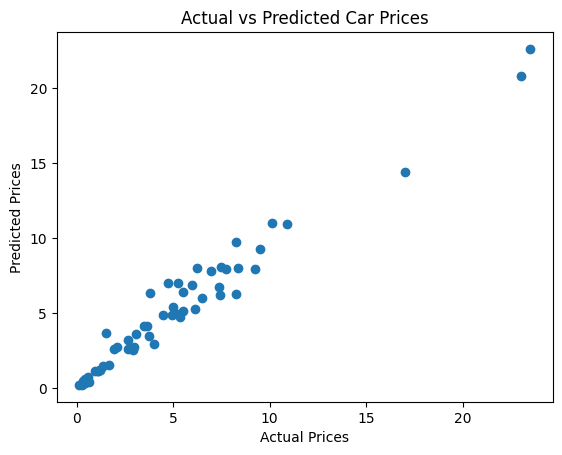


Example Prediction:
Predicted Selling Price: 0.4427999999999999


In [ ]:
# ================================
# 🚗 Car Price Prediction Project
# Google Colab Ready Code
# ================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ================================
# Step 2: Upload Dataset in Colab
# ================================

from google.colab import files
uploaded = files.upload()

# Load dataset (replace with your filename if different)
df = pd.read_csv("/content/car_prediction_data.csv")

print("First 5 Rows:")
display(df.head())

# ================================
# Step 3: Feature Engineering
# ================================

# Create Car Age feature
df['Car_Age'] = 2024 - df['Year']

# Drop unnecessary columns
if 'Car_Name' in df.columns:
    df = df.drop('Car_Name', axis=1)

if 'Year' in df.columns:
    df = df.drop('Year', axis=1)

# ================================
# Step 4: Define Features & Target
# ================================

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# ================================
# Step 5: Preprocessing Pipeline
# ================================

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ================================
# Step 6: Model Pipeline
# ================================

model = RandomForestRegressor(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# ================================
# Step 7: Train-Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
pipeline.fit(X_train, y_train)

# ================================
# Step 8: Predictions
# ================================

y_pred = pipeline.predict(X_test)

# ================================
# Step 9: Model Evaluation
# ================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 3))

# ================================
# Step 10: Visualization
# ================================

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# ================================
# Step 11: Example Prediction
# ================================

sample_data = X_test.iloc[:1]
predicted_price = pipeline.predict(sample_data)

print("\nExample Prediction:")
print("Predicted Selling Price:", predicted_price[0])